# Probability II
# Continuous Distributions

This article is part of a series, listed below:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20I%20-%20Discrete%20Distributions.ipynb">Probability I - Discrete Distributions</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20II%20-%20Continuous%20Distributions.ipynb">Probability II - Continuous Distributions</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20III%20-%20Gaussian%20Processes.ipynb">Probability III - Gaussian Processes</a>

<h1>Outline</h1>

- Exponential
- Gamma
- Beta
- Uniform
- Normal
- Multivariate Normal
- Student-t
- Chi-Square
- F-Distribution

A random variable is a mathematical formalization of a quantity or object which depends on random events. It is a mapping or function from possible outcomes in a sample space to a measurable space.

Continuous distributions have an infinite amount of points along an unbroken function, whereas discrete random variables are valued in a finite set, or intervals of real numbers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import arviz as az
plt.style.use('arviz-darkgrid')
plt.rcParams['figure.figsize'] = (6,4)

# Exponential

<u><i>Story:</i></u>

The Exponential distribution infers the probability of the waiting time between events. The Poisson distribution is used to describe a counting process where events happen at a random but given rate, and the Exponential distribution describes the probability of waiting times between events for the Poisson distribution.

<u><i>PDF:</i></u> 

$f(x) = \lambda e^{-\lambda x}$

<u><i>Expected Value:</i></u> $\frac{1}{\lambda}$

<u><i>Variance:</i></u> $\frac{1}{\lambda^2}$

<u><i>Derivation:</i></u>

The Exponential distribution is derived from the Poisson process, which models the occurrence of events in continuous time. 

- The probability of the first event in a Poisson process occurring after time $t$ is:

- $P(T_1 > t) = P(\text{no events in [0,t]}) = e^{-\lambda t}$

- The CDF of the time until the first event is $1 - e^{-\lambda t}$

- The PDF is the derivative of the CDF: $f(t) = \lambda e^{-\lambda t}$

<u><i>Relationships:</i></u>

The continuous Exponential and discrete Geometric distributions are analogs. The Geometric describes the number of trials needed to get the first success in a sequence of independent Bernoulli trials, and the Exponential describes the time until the first event in a Poisson process with rate $\lambda$.

<u><i>The Exponential Family and Maximum Entropy:</i></u>

When a researcher wants to build an unconventional model, entropy provides one useful principle to guide choice of probability distributions. Choosing the distribution with the largest entropy means spreading probability as evenly as possible. In the context of choosing a prior, it means choosing the least informative distribution consistent with any partial scientific knowledge we have about a parameter. 

Members of the Exponential family maximize entropy, and their PDF or PMF take the 'cannonical form' of 

$f(x | \theta) = h(x) ~exp(\eta(\theta) = T(x) = A(\theta))$</p>

- $x$ is the observed data</li>
- $\theta$ is the parameter or vector of parmaters of the distribution</li>
- $h(x)$ is the base measure function (or carrier measure)</li>
- $\eta(\theta)$ is the natural parameter (or vector of)</li>
- $T(x)$ is the sufficient statistic (or vector of)</li>
- $A(\theta)$ is the log-partition function (a.k.a. cumulant function), which ensures the distribution is properly normalized.</li>

<img src="img/exp_family.png" style="height: 350px; width:auto;">

<u><i>Conjugate Prior:</i></u>

- Likelihood: $X \sim Exponential(\lambda)$

- Conjugate Prior: $Gamma(\lambda \sim Gamma(\alpha, \beta))$

- Posterior: $Gamma(\lambda | X) \sim Gamma(\alpha + n, \beta + \sum x_i)$

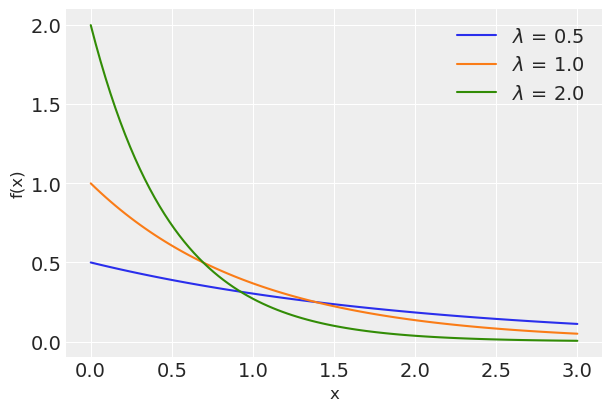

In [2]:
x = np.linspace(0, 3, 100)
for lam in [0.5, 1., 2.]:
    pdf = st.expon.pdf(x, scale=1.0/lam)
    plt.plot(x, pdf, label=r'$\lambda$ = {}'.format(lam))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Gamma

<u><i>Story:</i></u>

The Gamma distribution is used to model continuous variables that are always positive and have skewed distributions. It is a generalization of the Exponential (and Chi-Square) distribution, but while an Exponential random variables represents the waiting time for the first success under conditions of memoryless, the Gamma distribution gives us the waiting time until a number of successes occur. The total waiting time for $n$ arrivals is distributed $Gamma(n, \lambda)$.

<u><i>PDF:</i></u>

$f(x) = \frac{1}{\Gamma(a)} (\lambda x)^a e^{-\lambda x} \frac{1}{x}$

$\Gamma$ is the Gamma function:

- $\Gamma(a) = \int_0^{\infty} x^a e^{-x} \frac{dx}{x}, a \gt 0$

- $\Gamma(n) = (n-1)!$ if $n$ is a positive integer.

    <u><i>Expected Value:</i></u> $\frac{\alpha}{\lambda}$

    <u><i>Variance:</i></u> $\frac{\alpha}{\lambda^2}$

<u><i>Derivation:</i></u>

The Gamma can be seen as a generalization of the Exponential distribution. Taking $\alpha=1$, the $Gamma(1,\lambda)$ PDF is $f(y) = \lambda e^{-\lambda y}$, so the $Gamma(1, \lambda)$ and $Expo(\lambda)$ distributions are the same.

<u><i>Gamma as Convolution of Exponentials:</i></u>

Let $X, Y \sim Expo(\lambda)$. To find the distribution of $T=X+Y$, for $t \gt 0$, the convolution formula gives:

- $f_T(t) = \int_{-\infty}^{\infty} f_Y(t-x) f_X(x) ~dx$

- $f_T(t) = \int_0^t \lambda e^{-\lambda(t-x)} \lambda e^{-\lambda x} ~dx$

where we restricted the integral to be from $0$ to $t$ since we need $t-x \gt 0$ and $x \gt 0$ for the PDFs inside the integral to be nonzero. Simplifying, we have:

- $f_T(t) = \lambda^2 \int_0^t e^{-\lambda t} ~dx = \lambda^2 te^{-\lambda t}$

which is the $Gamma(2, \lambda)$ distribution.

<u><i>Special Cases:</i></u>

- The Exponential distribution is the special case $Gamma(1,\beta)$.

- $Beta(\alpha, \beta)$ is the special case $Gamma(\alpha + \beta, 1)$.

- The Chi-Square distribution with $n$ degrees of freedom is the special case $Gamma\left(\frac{n}{2}, \frac{1}{2}\right)$. It arises as the sum of squares of $n$ independent standard normal random variables.

<u><i>Shape of the Gamma:</i></u>

As $a$ increases, the PDF starts to look more symmetrical and bell-shaped, and increasing $\lambda$ compresses the PDF toward smaller values.

<u><i>Relationships:</i></u>

- The continuous $Gamma(\alpha, \beta)$ and the discrete Negative Binomial distribution are analogs. Specifically, if the number of events follows a Poisson process, the time until the $r^{th}$ event is Gamma distributed with shape parameter $r$ and rate parameter $\lambda$.

<u><i>Conjugate Prior:</i></u>

- Likelihood: $X \sim Gamma(\alpha, \beta)$</p>

- Conjugate Prior: $Gamma(\alpha \sim Gamma(a_0, b_0)) \text{ and } Gamma(c_0, d_0))$</p>

- Posterior: $Gamma(\alpha | X) \sim Gamma(a_0 + n \bar{x}, b_0 + n(1 - \bar{x})) \text{ and } (\beta | X) \sim Gamma(c_0 + n(1 - \bar{x}), d_0 + n \bar{x})$</p>

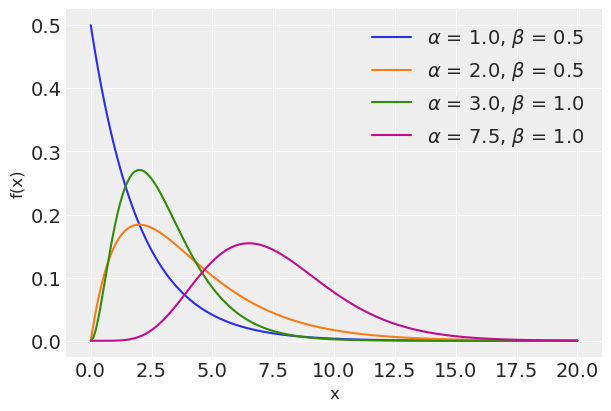

In [3]:
x = np.linspace(0, 20, 200)
alphas = [1., 2., 3., 7.5]
betas = [.5, .5, 1., 1.]
for a, b in zip(alphas, betas):
    pdf = st.gamma.pdf(x, a, scale=1.0/b)
    plt.plot(x, pdf, label=r'$\alpha$ = {}, $\beta$ = {}'.format(a, b))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Beta

<u><i>Story:</i></u>

The Beta distribution is a continuous distribution often dubbed the probability distribution of probabilities, as it is a continuous distribution on the interval $(0,1)$. It can be used to infer the probability of an event when we have information about the volumes of successes and failures.

<u><i>PDF:</i></u>

$f(x) = \frac{ \Gamma(a+b) }{ \Gamma(a) \Gamma(b) } x^{a-1} (1-x)^{b-1}, ~~x \in (0,1)$

- $\Gamma$ is the Gamma function (discussed above)

<u><i>Expected Value:</i></u> $\mu = \frac{a}{a+b}$</u>

<u><i>Variance:</i></u> $\frac{ \mu(1-\mu) }{ a+b+1 }$</u>

<u><i>Special Cases:</i></u>

The Beta distribution is a generalization of the Uniform distribution. The $Beta(1,1)$ and $Unif(0,1)$ distributions are the same. 

<u><i>Shape of the Beta:</i></u>

By varying the values of $a$ and $b$, the PDF takes on different shapes.<sup>[1]</sup>

- If $a \lt 1$and $ \lt 1$, the PDF is U-shaped and opens upward
- If $a \gt 1$and $ \gt 1$, the PDF opens downward
- If $a=b$, the PDF is symmetric about $0.5$
- If $a \gt b$, the PDF favors values lower than $0.5$
- If $a \lt b$, the PDF favors values greater than $0.5$

<u><i>Relationships:</i></u>

- A continuous analog of the Hypergeometric distribution used in Bayesian statistics. The Beta distribution serves as a prior for the proportion of successes in the population, and the resulting posterior is Beta-distributed.

- The generalization of the Beta distribution to higher dimensions is the Dirichlet distribution

<u><i>Conjugate Prior:</i></u>

- Likelihood: $X \sim Beta(\alpha, \beta)$

- Conjugate Prior: $Gamma(\alpha \sim Gamma(a_0, b_0)) \text{ and } Gamma(\beta \sim Gamma(c_0, d_0))$

- Posterior: $\text{Indep. Gammas}(\alpha | X) \sim Gamma(a_0 + n \bar{x}, b_0 + n(1 - \bar{x})) \text{ and } (\beta | X) \sim Gamma(c_0 + n(1 - \bar{x}), d_0 + n \bar{x})$

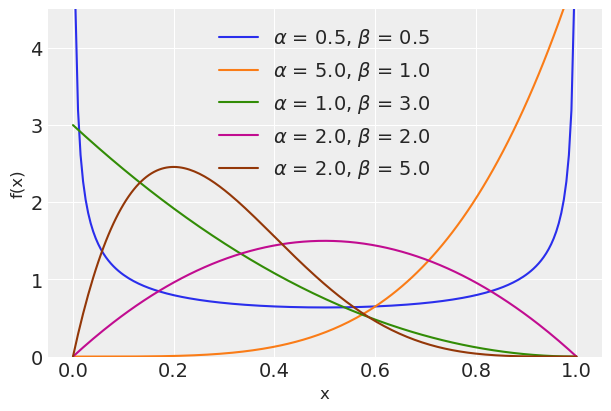

In [4]:
x = np.linspace(0, 1, 200)
alphas = [.5, 5., 1., 2., 2.]
betas = [.5, 1., 3., 2., 5.]
for a, b in zip(alphas, betas):
    pdf = st.beta.pdf(x, a, b)
    plt.plot(x, pdf, label=r'$\alpha$ = {}, $\beta$ = {}'.format(a, b))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.ylim(0, 4.5)
plt.legend(loc=9)
plt.show()

# Uniform

<u><i>Story:</i></u>

For a uniform distribution, the probability of a draw from any interval within the interval is proportional to the length of the interval. It theoretically takes on a constant value, however sampling variability does occur.

<u><i>PDF:</i></u> 

$f(x) = \frac{1}{b-a} ~~x \in (a,b)$

<u><i>Expected Value:</i></u> $\frac{a+b}{2}$

<u><i>Variance:</i></u> $\frac{(b-a)^2}{12}$

- <a href="https://proofwiki.org/wiki/Variance_of_Continuous_Uniform_Distribution">Proof of Variance</a>

<u><i>Special Cases:</i></u>
    
- A Unif(0,1) distribution is equivalent to a Beta(1,1) distribution.

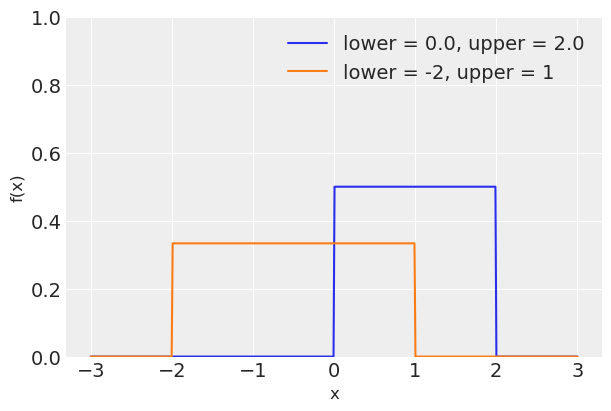

In [5]:
x = np.linspace(-3, 3, 500)
ls = [0., -2]
us = [2., 1]
for l, u in zip(ls, us):
    y = np.zeros(500)
    y[(x<u) & (x>l)] = 1.0/(u-l)
    plt.plot(x, y, label='lower = {}, upper = {}'.format(l, u))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.ylim(0, 1)
plt.legend(loc=1)
plt.show()

# Normal

<u><i>Story:</i></u>

The Normal distribution is widely used in statistics because the central limit theorem says that the sample mean of i.i.d. random variables will approach a Normal distribution as the sample size grows, regardless of the initial distribution.

The Normal distribution's location and form are determined by two parameters, the mean $\mu$ and variance $\sigma^2$. In the standard normal distribution, the mean, median and mode are equal. The shape of the normal curve depends only on the standard deviation, so all normal curves can be standardized such that $\mu=0$ and $\sigma=1$.

<u><i>PDF:</i></u> 

$f(x) = \frac{1}{\sigma \sqrt{2 \pi}} e^{ \frac{1}{2} \left( \frac{x-\mu}{\sigma} \right)^2 }, ~~x \in (-\infty, \infty)$
    
<u><i>Expected Value:</i></u> $\mu$

<u><i>Variance:</i></u> $\sigma^2$

<u><i>Conjugate Prior - Normal with Known Variance:</i></u>

- Likelihood: $X \sim Normal(\mu, \sigma^2) \text{ with known } \sigma^2$</p>

- Conjugate Prior: $Normal(\mu \sim Normal(\mu_o, \tau^2))$</p>

- Posterior: $Normal(\mu | X \sim Normal(\mu', \tau'^2))$, where $\mu$ and $\tau'^2$ depend on $\mu_0$, $\tau^2$, $\bar{x}$, and $\sigma^2$</p>
    
<u><i>Conjugate Prior - Normal with Unknown Variance:</i></u>

- Likelihood: $X \sim Normal(\mu, \sigma^2)$</p>

- Conjugate Prior: $InverseGamma(\mu_0, \mathcal{K}, \alpha, \beta)$</p>

- Posterior: $InverseGamma(\mu, \sigma^2 | X)$</p>

The inverse Gamma is simply $\frac{1}{Gamma(\alpha,\beta)}$

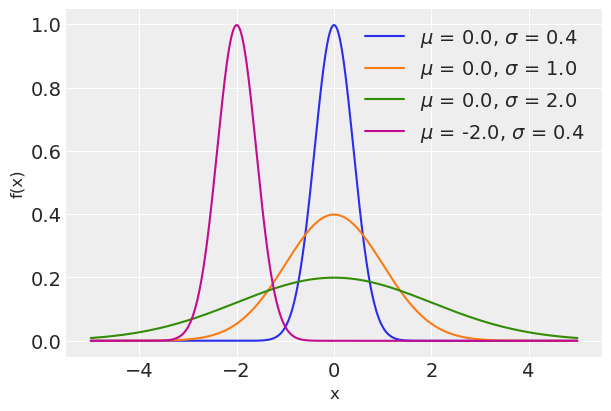

In [6]:
x = np.linspace(-5, 5, 1000)
mus = [0., 0., 0., -2.]
sigmas = [0.4, 1., 2., 0.4]
for mu, sigma in zip(mus, sigmas):
    pdf = st.norm.pdf(x, mu, sigma)
    plt.plot(x, pdf, label=r'$\mu$ = {}, $\sigma$ = {}'.format(mu, sigma))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Multivariate Normal

<u><i>Story:</i></u>

A known random vector $\mathbf{X} = (X_1, \ldots, X_k)$ has the multivariate Normal (MVN) distribution if every linear combination of the $X_j$ has a Normal distribution. Therefore, if $(X_1, X_2, X_3)$ is MVN, then so is the subvector $X_1, X_2$

A MVN is fully specified by knowing the mean of each component, the variance of each component, and the covariance or correlation between any two components.

<u><i>PDF:</i></u>

$
\mathcal{N}(\mathbf{y} | \mathbf{\mu}, \mathbf{\Sigma}) = 
\frac{1}{ (2 \pi)^{D/2} |\mathbf{\Sigma}|^{1/2} }
exp \left[ -\frac{1}{2} (\mathbf{y} - \mathbf{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{y} - \mathbf{\mu}) \right]     
$

- $D$ is the number of dimensions

<u><i>Expected Value:</i></u> $\mathbf{\mu}$

<u><i>Variance:</i></u> $\mathbf{\Sigma}$

<u><i>Marginals:</i></u>

Suppose $\mathbf{y} = (\mathbf{y}_1, \mathbf{y}_2)$ is jointly Gaussian with parameters $\mathbf{\mu}$, $\mathbf{\Sigma}$, and $\mathbf{\Sigma}^{-1} = \mathbf{\Lambda}$, where $\mathbf{\Lambda}$ is called the precision matrix. Then the marginals are given by:

- $p(\mathbf{y}_1) = \mathcal{N}(\mathbf{y}_1 | \mathbf{\mu}_1, \mathbf{\Sigma}_{11})$

- $p(\mathbf{y}_2) = \mathcal{N}(\mathbf{y}_2 | \mathbf{\mu}_2, \mathbf{\Sigma}_{22})$

<u><i>Posterior:</i></u>

The posterior conditional is given by:

- $p(\mathbf{y}_1 | \mathbf{y_2}) = \mathcal{N}(\mathbf{y}_1 | \mathbf{\mu}_{1,2}, \mathbf{\Sigma}_{1|2})$

- $\mathbf{\mu}_{1|2} = \mathbf{\mu}_1 + \mathbf{\Sigma}_{12} \mathbf{\Sigma}_{22}^{-1} (\mathbf{y}_2 - \mathbf{\mu}_2)$

- $\mathbf{\mu}_{1|2} = \mathbf{\mu}_1 - \mathbf{\Lambda}_{11}^{-1} \mathbf{\Lambda}_{12} (\mathbf{y}_2 - \mathbf{\mu}_2)$

- $\mathbf{\mu}_{1|2} = \mathbf{\Sigma}_{1|2} (\mathbf{\Lambda}_{11} \mathbf{\mu_1} - \mathbf{\Lambda}_{12} (\mathbf{y}_2 - \mathbf{\mu}_2))$

- $\mathbf{\Sigma}_{1|2} = \mathbf{\Sigma}_{11} - \mathbf{\Sigma}_{12} \mathbf{\Sigma}_{22}^{-1} \mathbf{\Sigma}_{21} = \mathbf{\Lambda}_{11}^{-1}$

<u><i>Conjugate Prior:</i></u>

- The Gaussian prior is a conjugate prior for the Gaussian likelihood, thus Gaussians are closed under Bayesian conditioning.

- The conjugate prior for the multivariate Gaussian distribution is a <a href="https://en.wikipedia.org/wiki/Normal-inverse-Wishart_distribution">Normal-Inverse-Wishart</a> distribution if both the mean and covariance are unknown. The Wishart distribution is a distribution over all positive semi-definite matrices, which applies to proper covariance matrices.

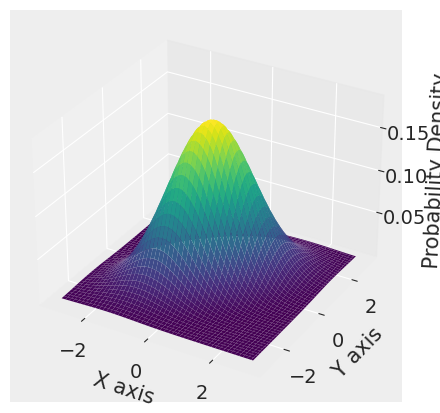

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal

# Parameters for the bivariate normal distribution
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]  # Diagonal covariance

# Create grid and multivariate normal
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
rv = multivariate_normal(mean, cov)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
Z = rv.pdf(pos)
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Probability Density')
plt.show()

# Student-t

<u><i>Story:</i></u>

T-Distributions are witnessed when sampling from data that are approximately Gaussian, and this phenomena makes for a useful shortcut when describing uncertainty or error, related to sampling for the purpose of estimating population statistics. Compared to the standard Gaussian distribution, it shows longer tails and taller shoulders.

Whereas the Gaussian distribution has two parameters, the t-distribution only has one - the number of degrees of freedom. Degrees of freedom equate to the number of pieces of information used to describe a population quantity. For example, the mean has $n$ degrees of freedom, since all $n$ observations in the sample are used to calculate the estimate of the population mean.

As $n$ approaches $\infty$, the t-distribution converges to a Gaussian.

<u><i>PDF:</i></u> $\frac{ \Gamma((n+1)/2) }{ \sqrt{n \pi} \Gamma(n/2) } (1 + x^2/n)^{-(n+1)/2}, ~~x \in (-\infty, \infty)$

- where $\Gamma$ is the gamma function (discussed above)

<u><i>Expected Value:</i></u> $0$ if $n \gt 1$

<u><i>Variance:</i></u> $\frac{n}{n-2}$ if $n \gt 2$


<u><i>Relationships:</i></u>

- The t-distribution results from a mixture of Gaussian distributions with mean μ and unknown variance distributed as an InverseGamma distribution.

- A t-distribution with one degree of freedom is the Cauchy distribution.

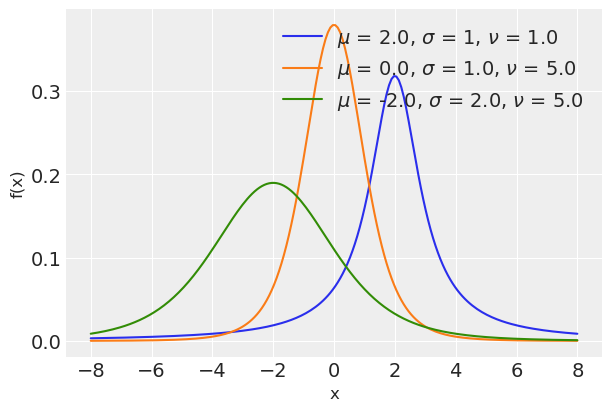

In [14]:
x = np.linspace(-8, 8, 200)
mus = [2., 0., -2.]
sigmas = [1, 1., 2.]
dfs = [1., 5., 5.]
for mu, sigma, df in zip(mus, sigmas, dfs):
    pdf = st.t.pdf(x, df, loc=mu, scale=sigma)
    plt.plot(x, pdf, label=r'$\mu$ = {}, $\sigma$ = {}, $\nu$ = {}'.format(mu, sigma, df))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Lognormal

<u><i>Story:</i></u>

If the logarithm of a set of values have a normal distribution, the values are said to havec a lognormal distribution. Sample from a $\mathcal{N}(\mu, \sigma)$, and $e^x$ will be log-normally distributed.

<u><i>PDF:</i></u>

$f(x \mid \mu, \tau) =
    \frac{1}{x} \sqrt{\frac{\tau}{2\pi}}
    \exp\left\{ -\frac{\tau}{2} (\ln(x)-\mu)^2 \right\}$

<u><i>Expected Value:</i></u> $\theta = e^{\mu + \sigma^2/2}$
    
<u><i>Variance:</i></u> $\theta^2(e^{\sigma^2}-1)$

<u><i>Product of Lognormals:</i></u> the product of independent lognormal variables is also lognormal.

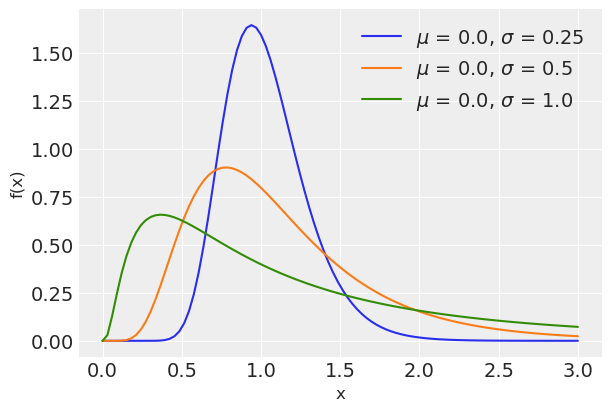

In [15]:
x = np.linspace(0, 3, 100)
mus = [0., 0., 0.]
sigmas = [.25, .5, 1.]
for mu, sigma in zip(mus, sigmas):
    pdf = st.lognorm.pdf(x, sigma, scale=np.exp(mu))
    plt.plot(x, pdf, label=r'$\mu$ = {}, $\sigma$ = {}'.format(mu, sigma))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Chi-Square 

<u><i>Story:</i></u>

The Chi-Square distribution is a special case of the Gamma; it is $Gamma(\frac{n}{2}, \frac{1}{2})$, and is the result of summing up $\nu$ random variables from the standard Normal distribution. In statistics, it is related to the distribution of sample variance, which can be used to estimate the true variance of a distribution.<sup>[5]</sup>

Consider a set of standard normal variables $z_i$, where $i = 1, \ldots, z$ that are i.i.d. with mean $\mu=0$ and standard deviation $\sigma=1$. Define a random variable $\chi^2 = \sum_i z_i^2$, for $i = 1, \ldots, \nu$ degrees of freedom. The variable has a Chi-Square distribution with $\nu$ (nu) degrees of freedom. The number of degrees of freedom dictates the shape.

<u><i>PDF:</i></u>

$\frac{ 1 }{ 2^{n/2} \Gamma(n/2) } x^{n/2-1} e^{-x/2}, ~~x \in (0, \infty)$

<u><i>Expected Value:</i></u> $n$

<u><i>Variance:</i></u> $2n$

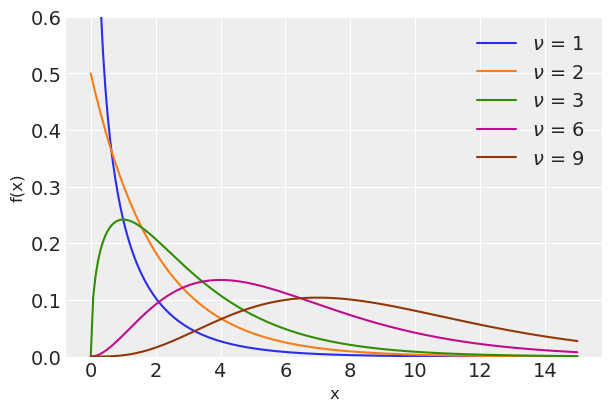

In [16]:
x = np.linspace(0, 15, 200)
for df in [1, 2, 3, 6, 9]:
    pdf = st.chi2.pdf(x, df)
    plt.plot(x, pdf, label=r'$\nu$ = {}'.format(df))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.ylim(0, 0.6)
plt.legend(loc=1)
plt.show()

# Dirichlet

<u><i>Story:</i></u>

The Dirichlet distribution lies in the simplex, which can be thought of as an n-dimensional triangle. A 1-simplex is a line, a 2-simplex is a triangle, a 3-simplex a tetrahedron, and so forth. This is because the output of the distribution is a $K$-length vector whose elements are restricted to be on the interval $[0,1]$ and sum up to $1$.

The Dirichlet is the generalization of the Beta. We use Beta for problems with two outcomes: one with probability $p$ and one with probability $1-p$ (and we only need to know $p$ in order to know $1-p$). Extending the Beta to three or more outcomes, we store the outcomes in the vector $\mathbf{\alpha}$ of length $K$.

<u><i>PDF:</i></u>

$f(\mathbf{\theta}; \mathbf{\alpha}) = \frac{1}{B(\mathbf{\alpha})} \prod_{i=1}^k x_i^{\alpha_i - 1}$

$B(\alpha)$ is the multinomial Beta function, which serves as a normalization constant.

$B(\alpha) = \frac{ \prod_{i=1}^k \Gamma(\alpha_i) }{ \Gamma(\sum_{i=1}^k \alpha_i }$

and $\Gamma$ is the Gamma function (discussed above).

<u><i>Expected Value:</i></u> $\frac{\alpha_i}{\sum_{i=k}^K}$

<u><i>Variance:</i></u> $\frac{EV(1-EV)}{1 = \sum_{k=1}^K \alpha_k}$

The next article in the series, on Bayesian inference, can be found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Probability%20III%20-%20Bayesian_Inference.ipynb">here</a>.